In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u
import glob

from scipy.ndimage import gaussian_filter
from skimage.measure import marching_cubes
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u


In [2]:
gc = pd.read_csv('mystery_gc.dat', comment="#", sep=r"\s+",  header=None, 
                 names=['F606W', 'F814W', 'F606W_err', 'F814W_err'])
gc

,F606W,F814W,F606W_err,F814W_err
0,18.276,17.307,0.002,0.002
1,19.133,17.939,0.001,0.001
2,18.969,18.064,0.004,0.004
3,19.016,18.238,0.001,0.001
4,18.853,18.377,0.001,0.001
...,...,...,...,...
3615,27.912,27.098,0.163,0.162
3616,27.728,27.292,0.137,0.192
3617,27.859,27.018,0.157,0.153
3618,27.775,27.164,0.143,0.174


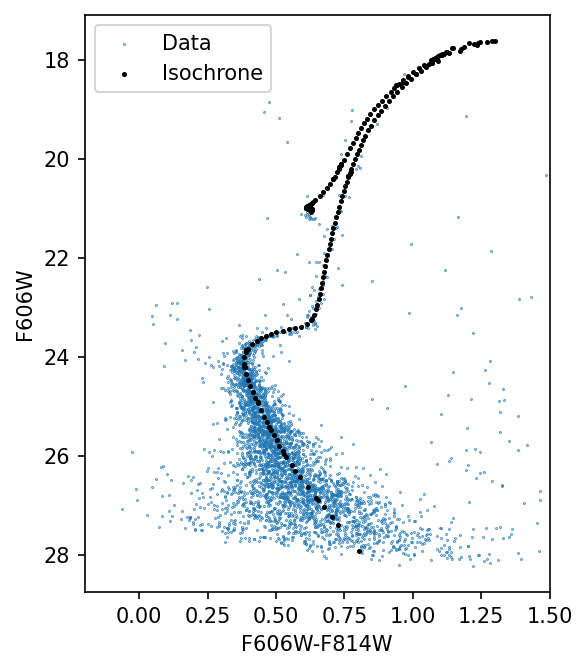

In [9]:
plt.figure(figsize=(4,5), dpi=150)
plt.scatter(gc.F606W-gc.F814W, gc.F606W, s=0.1, label='Data')
plt.gca().invert_yaxis()

distmod = 20.8
track = iso[(iso.logAge==9.85) & (iso.MH==-1.5) & (iso.F606Wmag+distmod<28)]
yav = 0.06
xav = 0.04
plt.scatter(track.F606Wmag-track.F814Wmag+xav, track.F606Wmag+distmod+yav, color='k', s=2, label='Isochrone')

plt.xlim(-0.2, 1.5)
plt.xlabel('F606W-F814W')
plt.ylabel('F606W')
plt.legend()
plt.show()

In [8]:
np.unique(iso.logAge.values)

array([ 9.7 ,  9.75,  9.8 ,  9.85,  9.9 ,  9.95, 10.  , 10.05, 10.1 ])

In [7]:
iso = pd.read_csv("isochrones.dat", comment="#", sep=r"\s+")
iso.keys()

Index(['Zini', 'MH', 'logAge', 'Mini', 'int_IMF', 'Mass', 'logL', 'logTe',
       'logg', 'label', 'McoreTP', 'C_O', 'period0', 'period1', 'period2',
       'period3', 'period4', 'pmode', 'Mloss', 'tau1m', 'X', 'Y', 'Xc', 'Xn',
       'Xo', 'Cexcess', 'Z', 'mbolmag', 'F435Wmag', 'F475Wmag', 'F555Wmag',
       'F606Wmag', 'F625Wmag', 'F775Wmag', 'F814Wmag'],
      dtype='object')

## Formal Fit(?):

In [16]:
import numpy as np
import pandas as pd

# Fixed parameters
A_606 = 0.06
A_814 = 0.04

def generate_synthetic_cmd(iso_sub, n_stars=1000, distance_modulus=20.85):
    """Generate synthetic CMD points from isochrone."""
    F606_iso = iso_sub['F606Wmag'].values
    F814_iso = iso_sub['F814Wmag'].values
    
    n_iso = len(F606_iso)
    masses = np.linspace(0.08, 1.0, n_iso)
    weights = masses**(-2.35)
    weights /= weights.sum()
    
    n_points = np.random.choice(n_iso, size=n_stars, p=weights)
    
    F606_syn = F606_iso[n_points] + distance_modulus + A_606
    F814_syn = F814_iso[n_points] + distance_modulus + A_814
    
    e606_syn = np.random.normal(0.03, 0.02, n_stars)
    e814_syn = np.random.normal(0.03, 0.02, n_stars)
    
    F606_syn += e606_syn
    F814_syn += e814_syn
    
    return np.vstack([F606_syn, F814_syn]).T, np.vstack([e606_syn, e814_syn]).T

def log_likelihood_obs_vs_model(obs_data, model_data, obs_errors):
    """Log-likelihood: each obs star vs nearest model point."""
    obs_pos = obs_data.T
    model_pos = model_data.T
    
    ll = 0.0
    for i in range(obs_pos.shape[1]):
        obs_point = obs_pos[:, i:i+1]
        diff = obs_point - model_pos
        
        obs_err_i = obs_errors[i]
        obs_err_expanded = np.tile(obs_err_i[:, np.newaxis], (1, model_data.shape[0]))
        
        mahalanobis2 = np.sum(diff**2 / (obs_err_expanded**2 + 1e-8), axis=0)
        ll_i = -0.5 * np.min(mahalanobis2)
        ll += ll_i
    
    return ll / len(obs_pos[0]) if len(obs_pos[0]) > 0 else -np.inf

def chi2_like_for_iso(gc, iso_sub, DM):
    """-2*logL for one isochrone at given DM (bright stars only)."""
    F606_obs = gc['F606W'].values - A_606
    F814_obs = gc['F814W'].values - A_814
    e606_obs = gc['F606W_err'].values
    e814_obs = gc['F814W_err'].values
    
    M606_abs = F606_obs - DM  # DM-dependent absolute mags
    bright_mask = M606_abs < 4.5
    if np.sum(bright_mask) < 5:
        return np.inf
    
    obs_subset = gc[bright_mask]
    obs_data = np.vstack([obs_subset['F606W'].values - A_606,
                          obs_subset['F814W'].values - A_814]).T
    obs_errors = np.vstack([obs_subset['F606W_err'].values,
                            obs_subset['F814W_err'].values]).T
    
    syn_data, _ = generate_synthetic_cmd(iso_sub, n_stars=5000, distance_modulus=DM)
    
    logL = log_likelihood_obs_vs_model(obs_data, syn_data, obs_errors)
    return -2 * logL

def grid_fit_drlica_wagner_full(gc, iso, DM_range=np.arange(20.75, 20.86, 0.01), M_thresh=4.5):
    """
    Full 3D grid: (MH, logAge, DM) → best chi^2 for each (MH, logAge) pair.
    
    DM scanned from 20.75 to 20.85 in 0.01 steps.
    """
    results = []
    
    for (mh, logage), iso_sub in iso.groupby(['MH', 'logAge']):
        chi2_vals = []
        DM_best_for_pair = None
        chi2_best_for_pair = np.inf
        
        for DM in DM_range:
            chi2 = chi2_like_for_iso(gc, iso_sub, DM)
            chi2_vals.append(chi2)
            
            if chi2 < chi2_best_for_pair:
                chi2_best_for_pair = chi2
                DM_best_for_pair = DM
        
        results.append({
            'MH': mh,
            'logAge': logage,
            'DM_best': DM_best_for_pair,
            'chi2_best': chi2_best_for_pair,
            'DM_range': DM_range.tolist(),
            'chi2_vals': chi2_vals
        })
    
    res_df = pd.DataFrame(results)
    best_idx = res_df['chi2_best'].idxmin()
    global_best = res_df.loc[best_idx]
    
    return res_df, global_best

# Usage:
res_df, best = grid_fit_drlica_wagner_full(gc, iso, DM_range=np.arange(20.75, 20.86, 0.01))
print("Global best fit:", best[['MH', 'logAge', 'DM_best', 'chi2_best']])
print("\nTop 5 fits:\n", res_df.nlargest(5, 'chi2_best')[['MH', 'logAge', 'DM_best', 'chi2_best']])


Global best fit: MH                  -0.9
logAge              9.95
DM_best            20.85
chi2_best    1630.931891
Name: 41, dtype: object

Top 5 fits:
      MH  logAge  DM_best    chi2_best
53 -0.6   10.10    20.79  1968.565021
52 -0.6   10.05    20.79  1902.596724
51 -0.6   10.00    20.81  1853.588620
49 -0.6    9.90    20.78  1851.191108
50 -0.6    9.95    20.84  1786.351219


In [19]:
print("\nTop 5 fits:\n", res_df.nsmallest(5, 'chi2_best')[['MH', 'logAge', 'DM_best', 'chi2_best']])



Top 5 fits:
      MH  logAge  DM_best    chi2_best
41 -0.9    9.95    20.85  1630.931891
38 -0.9    9.80    20.85  1634.702661
28 -1.2    9.75    20.83  1636.263517
29 -1.2    9.80    20.85  1642.201450
36 -0.9    9.70    20.85  1645.091059


In [60]:
print("Best-fit parameters:")
print(best)

,MH,logAge,DM_best,chi2
0,-2.1,9.70,18.477376,2.645332e+09
1,-2.1,9.75,16.405088,4.057075e+09
2,-2.1,9.80,16.485452,4.138567e+09
3,-2.1,9.85,18.050683,2.628197e+09
4,-2.1,9.90,18.067972,2.638997e+09
5,-2.1,9.95,18.190642,2.661839e+09
6,-2.1,10.00,18.331529,2.622854e+09
7,-2.1,10.05,16.692937,4.133983e+09
8,-2.1,10.10,16.639119,4.051357e+09
9,-1.8,9.70,20.217587,3.717275e+08
